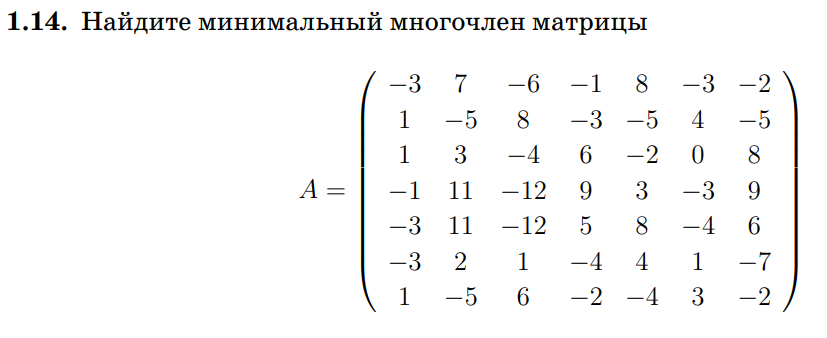

## 1. Характеристический многочлен

### Определение

Пусть $A$ — квадратная матрица размера $n\times n$ над полем $F$. **Характеристический многочлен** матрицы $A$ определяется как

$$
\chi_A(\lambda)=\det(\lambda I-A),
$$

где $I$ — единичная матрица размера $n\times n$.

Эквивалентно (с точностью до множителя $(-1)^n$):

$$
\chi_A(\lambda)=\det(A-\lambda I).
$$


### Основные свойства

- Корни $\chi_A(\lambda)$ — это **собственные значения** матрицы $A$.
- Старший коэффициент равен $1$ (многочлен унитарный).
- Свободный член равен $(-1)^n\det(A)$.


## 2. Минимальный многочлен

### Определение

**Аннулирующий многочлен** матрицы $A$ — многочлен $p(x)$, для которого

$$
p(A)=a_0 I+a_1 A+\cdots+a_k A^k=0.
$$

**Минимальный многочлен** $\mu_A(x)$ — это ненулевой унитарный аннулирующий многочлен наименьшей степени.

### Существование и единственность

- Существование: по теореме Гамильтона–Кэли $\chi_A(A)=0$.
- Единственность: если бы было два унитарных многочлена минимальной степени, их разность имела бы меньшую степень и тоже аннулировала $A$ — противоречие.

### Основные свойства

1. **Делимость.** $\mu_A(x)\mid \chi_A(x)$.

2. **Корни.** Корни $\mu_A(x)$ совпадают с собственными значениями $A$.

5. **Степень.** \(\deg\mu_A\le n\). Равенство достигается тогда и только тогда, когда \(\mu_A=\chi_A\) (такие матрицы называются **циклическими**).

7. **Связь с кратностями.** Каждый множитель $(\lambda-\lambda_i)$ входит в $\mu_A$ со степенью от $1$ до $n_i$ (кратности в $\chi_A$).

### Алгоритм поиска минимального многочлена вручную

1. Найти $\chi_A(\lambda)$.
2. Разложить $\chi_A(\lambda)$ на неприводимые множители:
   $$
   \chi_A(\lambda)=f_1(\lambda)^{n_1}f_2(\lambda)^{n_2}\cdots
   $$
3. Минимальный многочлен имеет вид
   $$
   \mu_A(\lambda)=f_1(\lambda)^{k_1}f_2(\lambda)^{k_2}\cdots,
   \qquad 1\le k_i\le n_i.
   $$
4. Для каждого множителя перебирать $k_i=1,2,\dots,n_i$ и проверять $p(A)=0$, начиная с меньших степеней. Первый подошедший многочлен — минимальный.



## Теорема Гамильтона–Кэли

Для любой квадратной матрицы $A$ над полем $F$ её характеристический многочлен, вычисленный от самой матрицы, равен нулевой матрице:
$$
\chi_A(A)=0.
$$
Иными словами, если
$$
\chi_A(\lambda)=\det(\lambda I-A)
$$

— характеристический многочлен матрицы $A$, то

$$
\chi_A(A)=0.
$$

Следовательно, характеристический многочлен является аннулирующим многочленом матрицы $A$. Поэтому минимальный многочлен $\mu_A(\lambda)$ делит характеристический многочлен:

$$
\mu_A(\lambda)\mid\chi_A(\lambda).
$$

### Следствие

Степень минимального многочлена не превосходит размера матрицы:

$$
\deg\mu_A\leq n,
$$

где $n$ — размер квадратной матрицы $A$.

In [1]:
import sympy as sp
from itertools import product

x = sp.symbols('x')

A = sp.Matrix([
    [-3, 7, -6, -1, 8, -3, -2],
    [1, -5, 8, -3, -5, 4, -5],
    [1, 3, -4, 6, -2, 0, 8],
    [-1, 11, -12, 9, 3, -3, 9],
    [-3, 11, -12, 5, 8, -4, 6],
    [-3, 2, 1, -4, 4, 1, -7],
    [1, -5, 6, -2, -4, 3, -2]
])


# ----------------------------------------
# 1. Характеристический многочлен
# ----------------------------------------

chi = A.charpoly(x).as_expr()

print("Характеристический многочлен:")
print(sp.factor(chi))


# ----------------------------------------
# 2. Минимальный многочлен
# ----------------------------------------

def matrix_polynomial(p, A):
    """
    Вычисляет p(A), где p — многочлен от x.
    Функция нужна для последующей проверки аннулирования матрицы многочленом
    """
    P = sp.Poly(p, x)

    # Нулевая матрица того же размера, что и переданная в функцию
    result = sp.zeros(*A.shape)

    for (power,), coeff in P.terms():
        result += coeff * A**power

    return result


def minimal_polynomial(A):
    """
    Ищет минимальный многочлен перебором делителей характеристического многочлена.
    Использует matrix_polynomial
    """

    chi = A.charpoly(x).as_expr()

    factors = sp.factor_list(chi)[1] # [(x, 3), (x - 1, 4)]

    # Перебираем степени множителей
    ranges = [
        range(1, multiplicity + 1)
        for factor, multiplicity in factors
    ] # [range(1, 4), range(1, 5)]

    candidates = []

    # Создаём список всех кандидатов на минимальный многочлен
    for powers in product(*ranges):

        p = sp.Integer(1)

        for (factor, _), power in zip(factors, powers):
            p *= factor**power

        candidates.append(p)

    # Сортируем по степени
    candidates.sort(key=sp.degree)

    # Ищем первый p, для которого p(A)=0
    for p in candidates:
        if matrix_polynomial(p, A).is_zero_matrix:
            return p


mu = minimal_polynomial(A)

print("\nМинимальный многочлен:")
print(mu)

Характеристический многочлен:
x**3*(x - 1)**4

Минимальный многочлен:
x**3*(x - 1)**2
